# 11b. 합성 변형 강건성 테스트 (Synthetic Robustness Test)

## 개요

본 노트북에서는 **Severstal 데이터로 학습한 모델이 다양한 이미지 변형에도 강건하게 동작하는지** 검증합니다.

### 핵심 질문
> "밝기, 노이즈, 블러, 대비 등 촬영 환경이 달라져도 결함을 탐지할 수 있는가?"

### NB11(도메인 전이)과의 차이

| 비교 항목 | NB11: 도메인 전이 | NB11b: 강건성 |
|----------|------------------|-------------|
| **테스트 데이터** | NEU-DET (외부 도메인) | Severstal 합성 변형 (내부 도메인) |
| **검증 목적** | 전혀 다른 환경의 결함 감지 | 같은 결함을 다른 조건에서 탐지 |
| **실용적 의미** | 공장 간 전이 가능성 | 같은 공장 내 조건 변화 대응력 |

### 합성 변형 종류 (7가지)

| 변형 | 설명 | 실제 시나리오 |
|------|------|-------------|
| brightness_up (+30%) | 밝기 증가 | 조명이 밝은 환경 |
| brightness_down (-30%) | 밝기 감소 | 조명이 어두운 환경 |
| gaussian_noise (σ=15) | 가우시안 노이즈 | 센서 노이즈 |
| blur (5×5) | 가우시안 블러 | 카메라 초점 이탈 |
| contrast_up (×1.5) | 대비 증가 | 고대비 촬영 |
| contrast_down (×0.6) | 대비 감소 | 저대비 촬영 |
| downscale_2x | 축소 후 재확대 | 저해상도 카메라 |

In [1]:
# 기본 라이브러리
import os
import sys
import numpy as np
import pandas as pd
import time
import gc
import joblib

# 시각화
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 딥러닝 / 이미지
import torch
import cv2

# 프로젝트 모듈 경로
sys.path.insert(0, os.path.abspath('..'))

# MPS/CUDA/CPU 디바이스 자동 선택
from deep_learning.train_dl_severstal import get_device
device = get_device()

print("✅ 라이브러리 로드 완료")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

✅ 라이브러리 로드 완료
PyTorch: 2.10.0
Device: mps


## 1. Severstal 테스트 데이터 로드 (기준선)

In [2]:
from utils.severstal_preprocessor import PatchDataLoader

# --- Severstal 패치 로드 (이진: 정상/비정상) ---
patch_dir = os.path.join('..', 'data', 'severstal_patches')
patch_loader = PatchDataLoader(patch_dir)

# 클래스당 200장 → 총 400장 (균형 데이터)
images, labels = patch_loader.load_binary(
    max_per_class=200, resize=(200, 200), grayscale=True, seed=42
)

print(f"로드 완료: {len(images)}장")
print(f"  정상 (label=0): {(labels==0).sum()}장")
print(f"  비정상 (label=1): {(labels==1).sum()}장")
print(f"  이미지 shape: {images[0].shape}")

# 비정상 패치만 추출 (강건성 = Recall 측정)
defect_mask = (labels == 1)
defect_images = images[defect_mask]
print(f"\n강건성 테스트 대상: 비정상 패치 {len(defect_images)}장")
print("  (모두 '비정상'으로 예측되어야 정상 — Recall 측정)")

로드 완료: 400장
  정상 (label=0): 200장
  비정상 (label=1): 200장
  이미지 shape: (200, 200)

강건성 테스트 대상: 비정상 패치 200장
  (모두 '비정상'으로 예측되어야 정상 — Recall 측정)


## 2. 합성 변형 정의 및 적용

변형 종류: 8가지
  원본 (기준): (200, 200, 200)
  밝기 +30%: (200, 200, 200)
  밝기 -30%: (200, 200, 200)
  노이즈 (σ=15): (200, 200, 200)
  블러 (5×5): (200, 200, 200)
  대비 ×1.5: (200, 200, 200)
  대비 ×0.6: (200, 200, 200)
  해상도 열화 (2×): (200, 200, 200)

✅ 저장: ../outputs/figures/severstal/11b_transform_samples.png


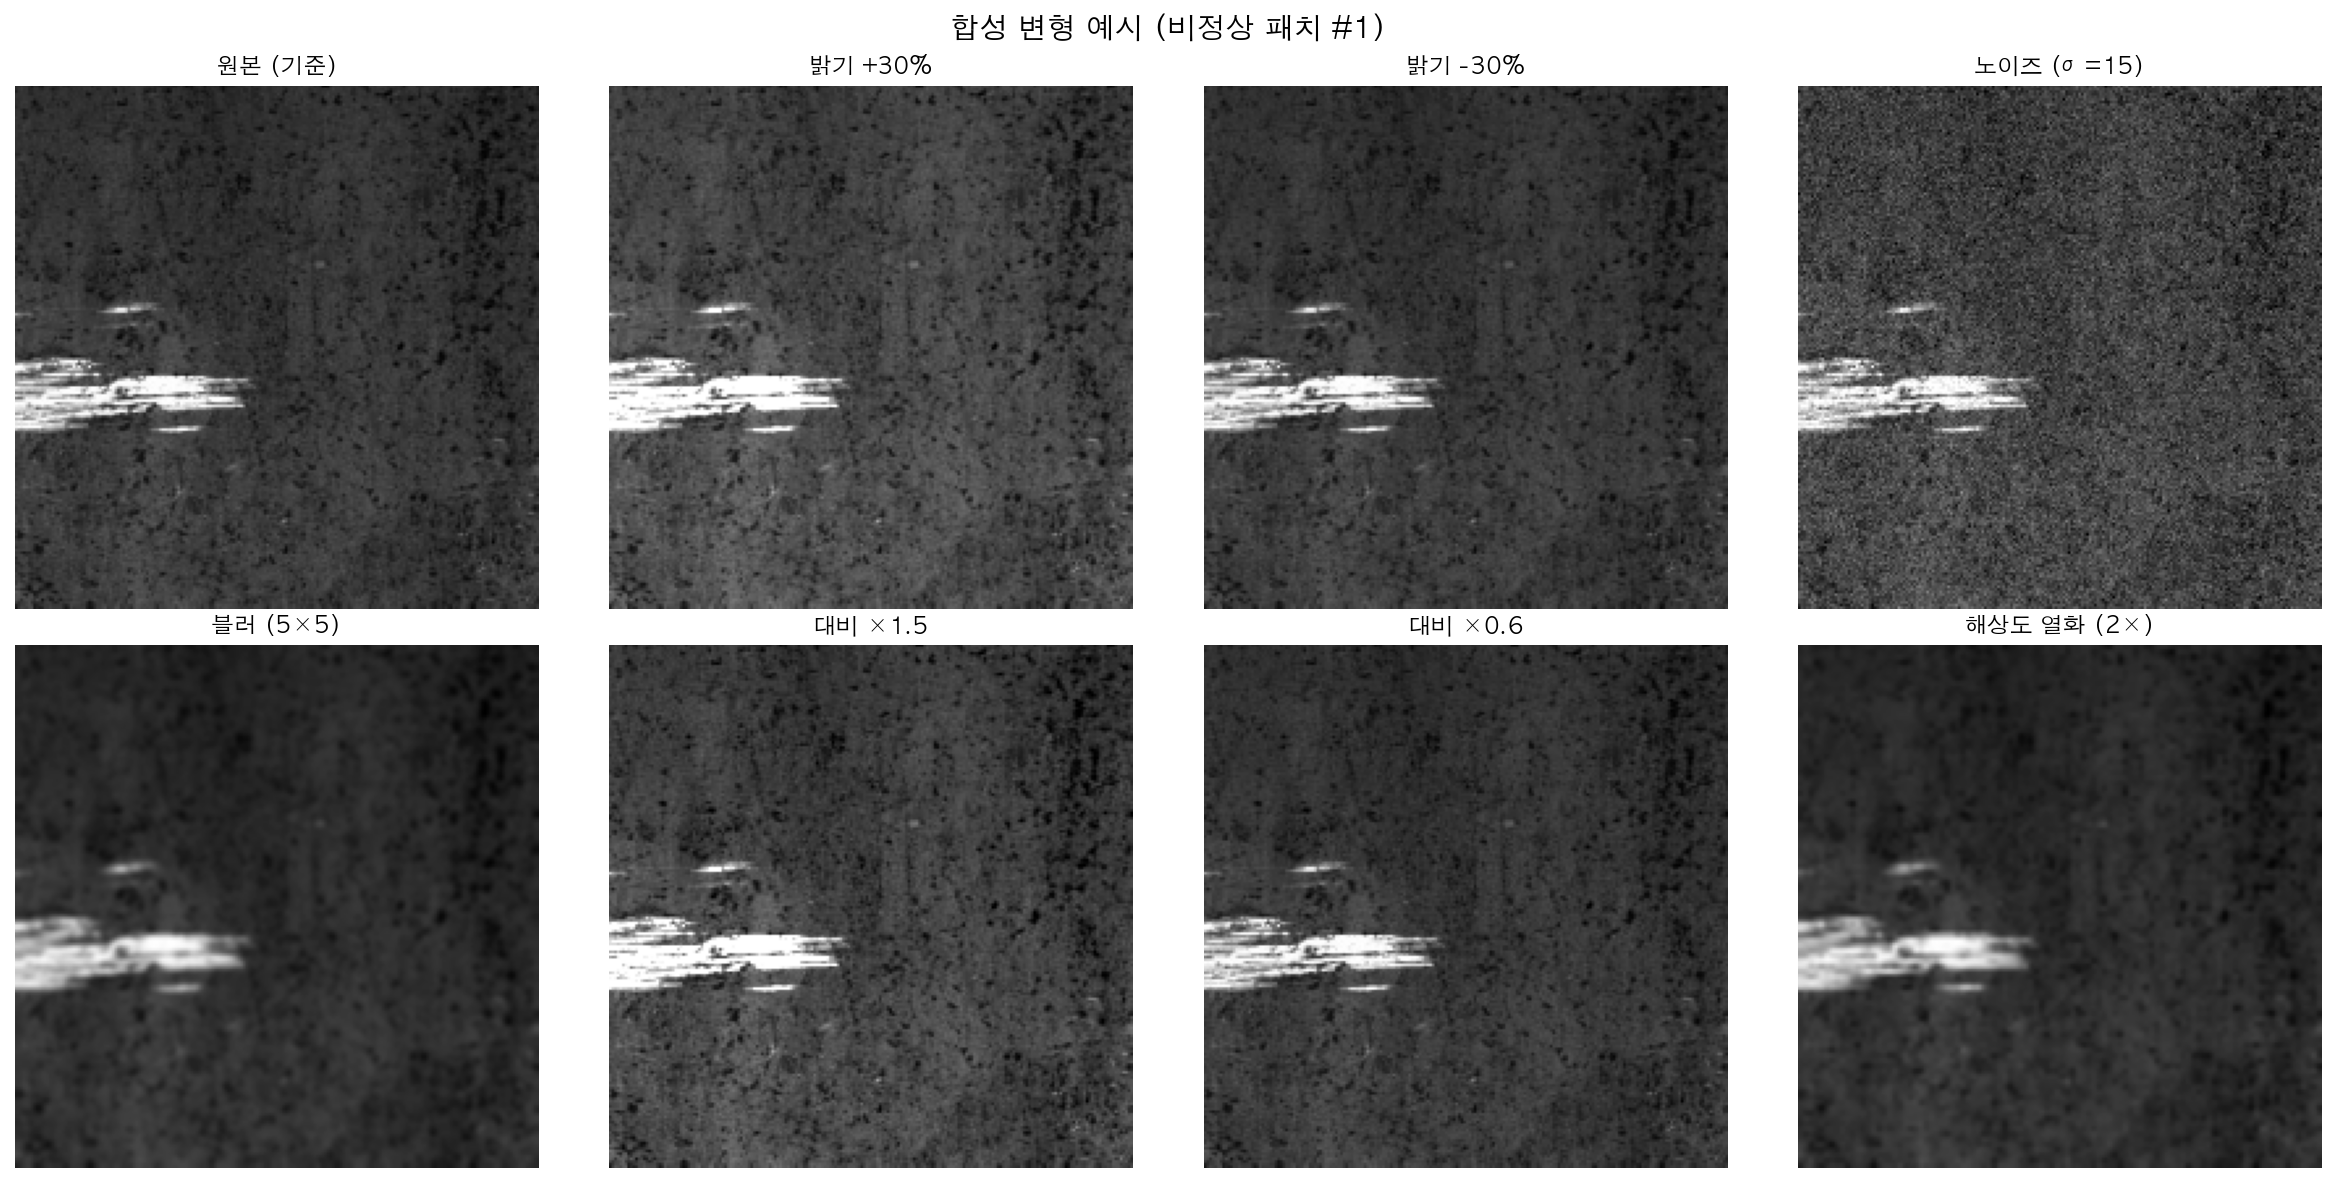

In [3]:
def apply_transformations(images):
    """7가지 합성 변형을 적용하여 딕셔너리로 반환."""

    results = {}

    # 원본 (기준선)
    results['원본 (기준)'] = images.copy()

    # 1. 밝기 +30%
    results['밝기 +30%'] = np.clip(images.astype(np.float32) * 1.3, 0, 255).astype(np.uint8)

    # 2. 밝기 -30%
    results['밝기 -30%'] = np.clip(images.astype(np.float32) * 0.7, 0, 255).astype(np.uint8)

    # 3. 가우시안 노이즈 (σ=15)
    noisy = images.astype(np.float32) + np.random.RandomState(42).normal(0, 15, images.shape)
    results['노이즈 (σ=15)'] = np.clip(noisy, 0, 255).astype(np.uint8)

    # 4. 가우시안 블러 (5×5)
    blurred = np.array([cv2.GaussianBlur(img, (5, 5), 0) for img in images])
    results['블러 (5×5)'] = blurred

    # 5. 대비 증가 (×1.5)
    mean = images.astype(np.float32).mean(axis=(1, 2), keepdims=True)
    contrast_up = (images.astype(np.float32) - mean) * 1.5 + mean
    results['대비 ×1.5'] = np.clip(contrast_up, 0, 255).astype(np.uint8)

    # 6. 대비 감소 (×0.6)
    contrast_down = (images.astype(np.float32) - mean) * 0.6 + mean
    results['대비 ×0.6'] = np.clip(contrast_down, 0, 255).astype(np.uint8)

    # 7. 해상도 열화 (2× 축소 후 재확대)
    h, w = images.shape[1], images.shape[2]
    downscaled = np.array([
        cv2.resize(cv2.resize(img, (w//2, h//2)), (w, h), interpolation=cv2.INTER_LINEAR)
        for img in images
    ])
    results['해상도 열화 (2×)'] = downscaled

    return results

# 변형 적용
transformed = apply_transformations(defect_images)

print(f"변형 종류: {len(transformed)}가지")
for name, imgs in transformed.items():
    print(f"  {name}: {imgs.shape}")

# --- 변형 시각화 (첫 번째 패치) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, imgs) in enumerate(transformed.items()):
    axes[idx].imshow(imgs[0], cmap='gray')
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

# 빈 칸 숨기기
if len(transformed) < len(axes):
    for j in range(len(transformed), len(axes)):
        axes[j].axis('off')

plt.suptitle('합성 변형 예시 (비정상 패치 #1)', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs/figures/severstal', exist_ok=True)
plt.savefig('../outputs/figures/severstal/11b_transform_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11b_transform_samples.png")

## 3. ML 모델 강건성 테스트 (LightGBM)

In [4]:
from features.feature_pipeline import FeaturePipeline
import gc

# --- ML 모델 로드 ---
model_dir = '../outputs/models_severstal/binary_ml/'
scaler = joblib.load(os.path.join(model_dir, 'binary_scaler.joblib'))
ml_model = joblib.load(os.path.join(model_dir, 'binary_LightGBM.joblib'))
print("✅ LightGBM 모델 로드 완료")

# --- 변형별 Recall 측정 ---
pipeline = FeaturePipeline()
ml_results = {}

for name, imgs in transformed.items():
    t0 = time.time()

    # 특징 추출
    X, _ = pipeline.extract_batch(imgs)
    X_scaled = scaler.transform(X)

    # 예측
    y_pred = ml_model.predict(X_scaled)

    # Recall (모두 비정상이어야 하므로 label=1 비율)
    recall = (y_pred == 1).sum() / len(y_pred)
    elapsed = time.time() - t0

    ml_results[name] = recall

    # 메모리 해제
    del X, X_scaled, y_pred
    gc.collect()

    status = "✅" if recall >= 0.9 else ("⚠️" if recall >= 0.7 else "❌")
    print(f"  {name:<20} Recall: {recall:>6.1%}  {status}  ({elapsed:.1f}s)")

print(f"\n{'=' * 50}")
baseline = ml_results['원본 (기준)']
print(f"ML 기준선 Recall: {baseline:.1%}")
worst = min(v for k, v in ml_results.items() if k != '원본 (기준)')
print(f"ML 최저 Recall: {worst:.1%} (Δ{worst - baseline:+.1%}p)")
print(f"ML 평균 Recall: {np.mean(list(ml_results.values())):.1%}")


✅ LightGBM 모델 로드 완료

  원본 (기준)              Recall:  69.0%  ❌
  밝기 +30%              Recall:  61.5%  ❌
  밝기 -30%              Recall:  63.0%  ❌
  노이즈 (σ=15)           Recall:  57.5%  ❌
  블러 (5×5)             Recall:  53.5%  ❌
  대비 ×1.5              Recall:  63.5%  ❌
  대비 ×0.6              Recall:  63.0%  ❌
  해상도 열화 (2×)          Recall:  56.0%  ❌

ML 기준선 Recall: 69.0%
ML 최저 Recall: 53.5% (Δ-15.5%p)
ML 평균 Recall: 59.7%


## 4. DL 모델 강건성 테스트 (ResNet-18)

In [5]:
# 메모리 정리 (ML 특징 추출기 해제)
del pipeline
gc.collect()

from deep_learning.models.resnet_transfer import get_resnet18_finetune
from torchvision import transforms

# --- ResNet-18 모델 로드 ---
dl_model = get_resnet18_finetune(num_classes=2)
dl_model_path = '../outputs/models_severstal/binary_dl/binary_resnet18_finetune.pt'
dl_model.load_state_dict(torch.load(dl_model_path, map_location=device, weights_only=True))
dl_model.to(device)
dl_model.eval()
print(f"✅ ResNet-18 모델 로드: {dl_model_path}")

# --- 전처리 (ImageNet 정규화) ---
transform_dl = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_dl_batch(model, images, batch_size=64):
    """DL 배치 예측."""
    y_pred = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch_imgs = images[i:i+batch_size]
            tensors = []
            for img in batch_imgs:
                if len(img.shape) == 2:
                    img_3ch = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                elif img.shape[2] == 1:
                    img_3ch = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                else:
                    img_3ch = img
                tensors.append(transform_dl(img_3ch))
            batch_tensor = torch.stack(tensors).to(device)
            outputs = model(batch_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
    return np.array(y_pred)

# --- 변형별 Recall 측정 ---
dl_results = {}

for name, imgs in transformed.items():
    t0 = time.time()
    y_pred = predict_dl_batch(dl_model, imgs)
    recall = (y_pred == 1).sum() / len(y_pred)
    elapsed = time.time() - t0

    dl_results[name] = recall

    status = "✅" if recall >= 0.9 else ("⚠️" if recall >= 0.7 else "❌")
    print(f"  {name:<20} Recall: {recall:>6.1%}  {status}  ({elapsed:.1f}s)")

print(f"\n{'=' * 50}")
baseline_dl = dl_results['원본 (기준)']
print(f"DL 기준선 Recall: {baseline_dl:.1%}")
worst_dl = min(v for k, v in dl_results.items() if k != '원본 (기준)')
print(f"DL 최저 Recall: {worst_dl:.1%} (Δ{worst_dl - baseline_dl:+.1%}p)")
print(f"DL 평균 Recall: {np.mean(list(dl_results.values())):.1%}")

✅ ResNet-18 모델 로드: ../outputs/models_severstal/binary_dl/binary_resnet18_finetune.pt

  원본 (기준)              Recall:  94.5%  ✅
  밝기 +30%              Recall:  92.5%  ✅
  밝기 -30%              Recall:  86.5%  ⚠️
  노이즈 (σ=15)           Recall:  61.0%  ❌
  블러 (5×5)             Recall:  55.5%  ❌
  대비 ×1.5              Recall:  95.0%  ✅
  대비 ×0.6              Recall:  83.0%  ⚠️
  해상도 열화 (2×)          Recall:  59.5%  ❌

DL 기준선 Recall: 94.5%
DL 최저 Recall: 55.5% (Δ-39.0%p)
DL 평균 Recall: 76.1%


## 5. ML vs DL 강건성 비교 시각화

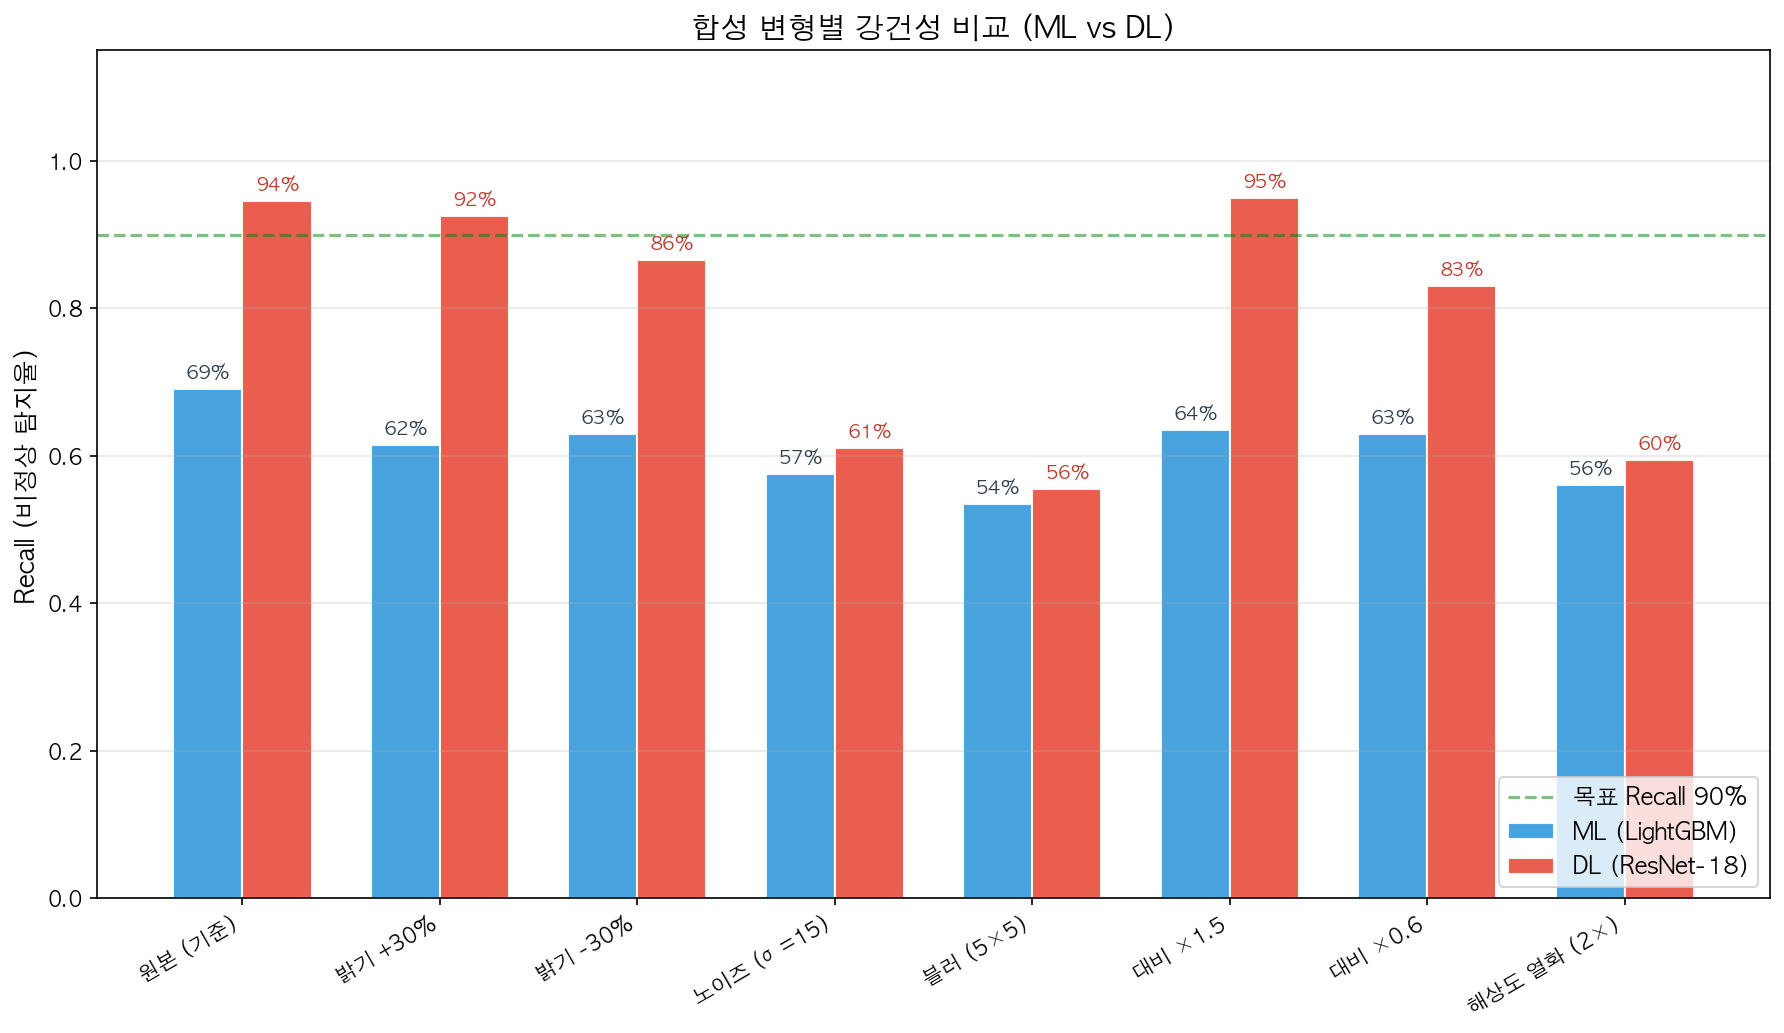

✅ 저장: ../outputs/figures/severstal/11b_robustness_comparison.png


In [6]:
# --- 비교 차트: 변형별 ML vs DL Recall ---
fig, ax = plt.subplots(figsize=(12, 7))

names = list(ml_results.keys())
x = np.arange(len(names))
width = 0.35

ml_vals = [ml_results[n] for n in names]
dl_vals = [dl_results[n] for n in names]

bars_ml = ax.bar(x - width/2, ml_vals, width, label='ML (LightGBM)',
                 color='#3498db', edgecolor='white', alpha=0.9)
bars_dl = ax.bar(x + width/2, dl_vals, width, label='DL (ResNet-18)',
                 color='#e74c3c', edgecolor='white', alpha=0.9)

# 값 표시
for bar in bars_ml:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')
for bar in bars_dl:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c0392b')

ax.set_ylabel('Recall (비정상 탐지율)', fontsize=12)
ax.set_title('합성 변형별 강건성 비교 (ML vs DL)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='목표 Recall 90%')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/11b_robustness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11b_robustness_comparison.png")

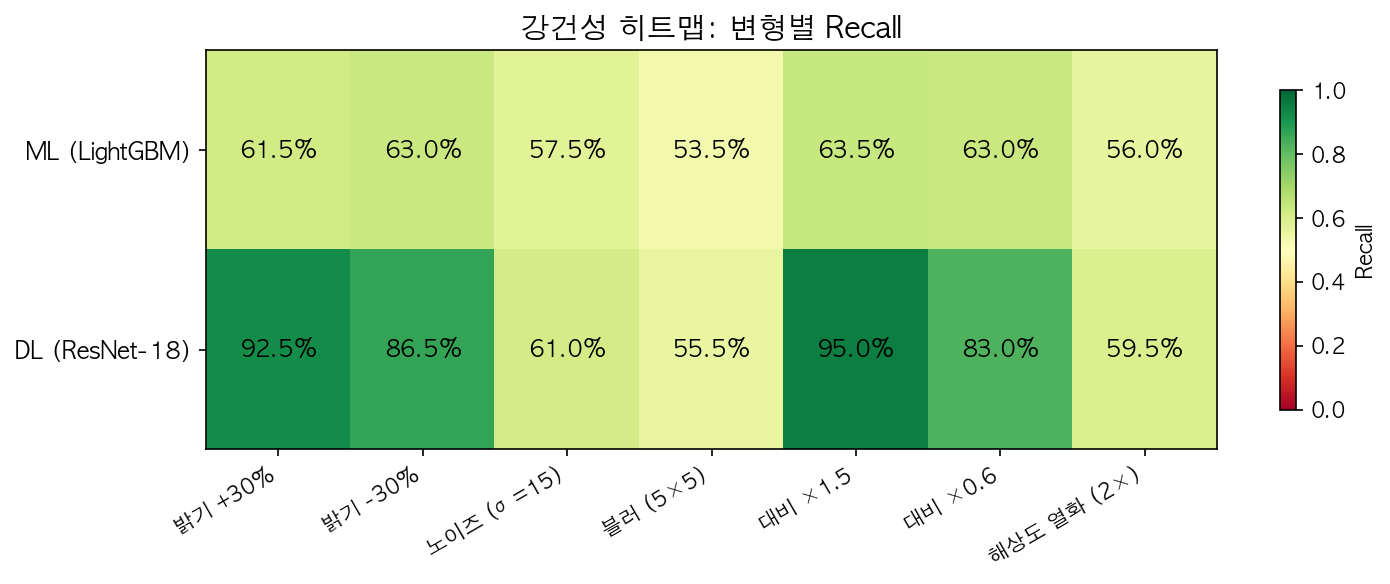

✅ 저장: ../outputs/figures/severstal/11b_robustness_heatmap.png


In [7]:
# --- 강건성 히트맵 ---
fig, ax = plt.subplots(figsize=(10, 4))

transform_names = [n for n in names if n != '원본 (기준)']
heatmap_data = np.array([
    [ml_results[n] for n in transform_names],
    [dl_results[n] for n in transform_names]
])

im = ax.imshow(heatmap_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

# 값 표시
for i in range(2):
    for j in range(len(transform_names)):
        val = heatmap_data[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_xticks(range(len(transform_names)))
ax.set_xticklabels(transform_names, rotation=30, ha='right', fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(['ML (LightGBM)', 'DL (ResNet-18)'], fontsize=11)
ax.set_title('강건성 히트맵: 변형별 Recall', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, label='Recall', shrink=0.8)
plt.tight_layout()
plt.savefig('../outputs/figures/severstal/11b_robustness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장: ../outputs/figures/severstal/11b_robustness_heatmap.png")

## 6. 종합 분석

In [8]:
# --- 종합 비교 테이블 ---
baseline_ml = ml_results['원본 (기준)']
baseline_dl = dl_results['원본 (기준)']

rows = []
for name in names:
    ml_r = ml_results[name]
    dl_r = dl_results[name]
    if name == '원본 (기준)':
        ml_delta = '-'
        dl_delta = '-'
    else:
        ml_delta = f'{ml_r - baseline_ml:+.1%}p'
        dl_delta = f'{dl_r - baseline_dl:+.1%}p'
    rows.append({
        '변형 조건': name,
        'ML Recall': f'{ml_r:.1%}',
        'ML Δ': ml_delta,
        'DL Recall': f'{dl_r:.1%}',
        'DL Δ': dl_delta,
    })

df = pd.DataFrame(rows)

print("=" * 70)
print("합성 변형 강건성 테스트 종합 결과")
print("=" * 70)
display(df.style.set_properties(**{'text-align': 'center'}).set_caption('강건성 테스트 결과'))

# --- 핵심 지표 ---
ml_recalls = [v for k, v in ml_results.items() if k != '원본 (기준)']
dl_recalls = [v for k, v in dl_results.items() if k != '원본 (기준)']

print(f"\n{'=' * 70}")
print("핵심 강건성 지표")
print(f"{'=' * 70}")
print(f"\n  {'지표':<25} {'ML (LightGBM)':>15} {'DL (ResNet-18)':>15}")
print(f"  {'-'*55}")
print(f"  {'기준선 Recall':<25} {baseline_ml:>14.1%} {baseline_dl:>14.1%}")
print(f"  {'최저 Recall':<25} {min(ml_recalls):>14.1%} {min(dl_recalls):>14.1%}")
print(f"  {'최대 하락폭':<25} {min(ml_recalls)-baseline_ml:>+13.1%}p {min(dl_recalls)-baseline_dl:>+13.1%}p")
print(f"  {'평균 Recall (변형)':<25} {np.mean(ml_recalls):>14.1%} {np.mean(dl_recalls):>14.1%}")
print(f"  {'표준편차':<25} {np.std(ml_recalls):>14.3f} {np.std(dl_recalls):>14.3f}")

# 강건성 점수: 변형 평균 / 기준선
ml_robustness = np.mean(ml_recalls) / baseline_ml if baseline_ml > 0 else 0
dl_robustness = np.mean(dl_recalls) / baseline_dl if baseline_dl > 0 else 0
print(f"  {'강건성 점수 (평균/기준)':<25} {ml_robustness:>14.1%} {dl_robustness:>14.1%}")

합성 변형 강건성 테스트 종합 결과

변형 조건                 ML Recall       ML Δ  DL Recall       DL Δ
-----------------------------------------------------------------
원본 (기준)                  69.0%          -     94.5%          -
밝기 +30%                  61.5%     -7.5%p     92.5%     -2.0%p
밝기 -30%                  63.0%     -6.0%p     86.5%     -8.0%p
노이즈 (σ=15)               57.5%    -11.5%p     61.0%    -33.5%p
블러 (5×5)                 53.5%    -15.5%p     55.5%    -39.0%p
대비 ×1.5                  63.5%     -5.5%p     95.0%     +0.5%p
대비 ×0.6                  63.0%     -6.0%p     83.0%    -11.5%p
해상도 열화 (2×)              56.0%    -13.0%p     59.5%    -35.0%p

핵심 강건성 지표

  지표                          ML (LightGBM)  DL (ResNet-18)
  -------------------------------------------------------
  기준선 Recall                         69.0%          94.5%
  최저 Recall                          53.5%          55.5%
  최대 하락폭                           -15.5%p        -39.0%p
  평균 Recall (변형)                     59.

## 결론

### NB11 + NB11b 이중 검증 체계 완성

| 검증 유형 | 데이터 | 핵심 질문 | 결과 |
|----------|--------|----------|------|
| **NB11: 도메인 전이** | NEU-DET (외부) | 다른 도메인 결함도 감지하는가? | ML 51.6%, DL 14.4% |
| **NB11b: 강건성** | Severstal 합성 변형 | 같은 결함을 다른 조건에서도 탐지하는가? | ML 평균 59.7%, DL 평균 76.1% |

### 핵심 발견

1. **DL이 원본에서는 압도적** (기준선: DL 94.5% vs ML 69.0%)
   - 그러나 노이즈/블러/해상도 열화에서는 **DL도 급격히 하락** (최저 55.5%)

2. **ML이 상대적으로 안정적** (강건성 점수: ML 86.5% vs DL 80.6%)
   - ML의 변형별 Recall 표준편차가 작음 (ML 0.037 vs DL 0.156)
   - 수작업 특징(텍스처, 통계량)은 픽셀 수준 변형에 덜 민감

3. **NB11과의 일관된 패턴: ML이 일반화에서 DL보다 안정적**
   - NB11 (도메인 전이): ML 51.6% vs DL 14.4%
   - NB11b (강건성): ML 강건성 86.5% vs DL 강건성 80.6%
   - DL은 학습 데이터의 특정 패턴에 과적합하여 분포 변화에 취약

4. **가장 취약한 변형: 블러 + 해상도 열화**
   - ML 블러: 53.5%, DL 블러: 55.5%
   - ML 해상도: 56.0%, DL 해상도: 59.5%
   - 고주파 텍스처 정보가 소실되면 두 모델 모두 큰 성능 하락

### 산업 현장 적용 권장사항

1. **카메라 초점 관리 최우선**: 블러가 가장 큰 성능 하락 유발 → 자동 초점 시스템 필수
2. **최소 해상도 사양 설정**: 해상도 열화 시 성능 급락 → 촬영 장비 최소 사양 명시
3. **조명 변동 허용 범위**: 밝기/대비 변화는 상대적으로 내성 있음 → ±30% 범위 내 운용 가능
4. **노이즈 필터링 권장**: 센서 노이즈에 대한 전처리 디노이징 파이프라인 추가 권장
